# BA3093 Teaching Demo: EV Charging Simulation and Risk Analysis

This notebook is a teaching-oriented walkthrough for the BA3093 group project.

It covers both technical streams:

- Option A: Monte Carlo simulation for profit-risk analysis.
- Option B: Queuing analysis (M/M/c baseline + M/G/c correction).

The notebook is structured to match report requirements:

1. Problem introduction
2. Data and parameters
3. Model design
4. Results and analysis
5. Sensitivity analysis
6. Conclusion and recommendations

## 1) Project directories, dependencies, and output conventions

We define standard folders for reproducibility:

- `data/`: source data
- `backend/`: model code
- `report_assets/`: exported figures
- `report/`: report outputs
- `notebooks/`: teaching notebooks

We also import required libraries for statistics, simulation, and visualization.

In [7]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional libraries (used if available)
try:
    import seaborn as sns
except Exception:
    sns = None

from scipy import stats

ROOT = Path.cwd()
if not (ROOT / "backend").exists() and (ROOT.parent / "backend").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
BACKEND_DIR = ROOT / "backend"
ASSET_DIR = ROOT / "report_assets"
REPORT_DIR = ROOT / "report"
NOTEBOOK_DIR = ROOT / "notebooks"

for d in [ASSET_DIR, REPORT_DIR, NOTEBOOK_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(BACKEND_DIR))

from data_processor import load_baseline_data
from queuing_model import QueuingSimulator
from monte_carlo import MonteCarloSimulator

plt.style.use("seaborn-v0_8-whitegrid")
print("ROOT:", ROOT)
print("Data exists:", DATA_DIR.exists())

ROOT: /Users/zhuzelin/Desktop/sr/小组作业
Data exists: True


## 2) Markdown report template, LaTeX formulas, and image embedding

The report uses Markdown + LaTeX:

- Inline: $\rho = \lambda / (c\mu)$
- Block:

$$
W_q^{M/G/c} \approx W_q^{M/M/c}\times\frac{1+CV^2}{2}
$$

Below we generate a minimal template in `report/report_template.md`.

In [8]:
report_template = """# Group Report Template\n\n## Cover Page\n- Group Number: [Fill]\n- Members: [Fill]\n\n## Problem Introduction\n[Business problem and why simulation/queuing is appropriate.]\n\n## Model Formula\n$$\\rho = \\frac{\\lambda}{c\\mu}$$\n\n## Figure Example\n![Queue Curve](../report_assets/fig_04_queue_sensitivity_curve.png)\n\n## References\n[APA format]\n"""

template_path = REPORT_DIR / "report_template.md"
template_path.write_text(report_template, encoding="utf-8")
print("Saved:", template_path)

Saved: /Users/zhuzelin/Desktop/sr/小组作业/report/report_template.md


## 3) Data loading, cleaning, and parameter table generation

We read core CSV files, check missing values, and build a parameter table directly reusable in the report.

In [9]:
df_inf = pd.read_csv(DATA_DIR / "inf.csv")
df_dur = pd.read_csv(DATA_DIR / "duration.csv")
df_occ = pd.read_csv(DATA_DIR / "occupancy.csv")
df_vol = pd.read_csv(DATA_DIR / "volume-11kW.csv")
df_ep = pd.read_csv(DATA_DIR / "e_price.csv")
df_sp = pd.read_csv(DATA_DIR / "s_price.csv")

print("Shapes:")
for name, df in [("inf", df_inf), ("duration", df_dur), ("occupancy", df_occ), ("volume", df_vol), ("e_price", df_ep), ("s_price", df_sp)]:
    print(name, df.shape)

print("\nMissing values:")
for name, df in [("inf", df_inf), ("duration", df_dur), ("occupancy", df_occ), ("volume", df_vol), ("e_price", df_ep), ("s_price", df_sp)]:
    print(name, int(df.isna().sum().sum()))

baseline = load_baseline_data()
parameter_table = pd.DataFrame([
    ["lambda", "Arrival rate", baseline["lambda_rate"], "sessions/hour/station", "Little's Law"],
    ["mu", "Service rate", baseline["mu"], "sessions/hour/pile", "1/mean service duration"],
    ["c", "Number of servers", baseline["c"], "chargers", "mean charge_count rounded"],
    ["CV", "Service-time coefficient of variation", baseline["service_time_cv"], "-", "std/mean of service durations"],
    ["wait_cost_per_minute", "Wait penalty unit cost", baseline["wait_cost_per_minute"], "RMB/(veh*min)", "managerial assumption"],
], columns=["Variable", "Meaning", "Value", "Unit", "Estimation / Assumption"])
parameter_table

Shapes:
inf (1362, 7)
duration (4344, 276)
occupancy (4344, 276)
volume (4344, 276)
e_price (4344, 276)
s_price (4344, 276)

Missing values:
inf 0
duration 0
occupancy 0
volume 0
e_price 0
s_price 0


,Variable,Meaning,Value,Unit,Estimation / Assumption
0,lambda,Arrival rate,3.068221,sessions/hour/station,Little's Law
1,mu,Service rate,1.381460,sessions/hour/pile,1/mean service duration
2,c,Number of servers,13.000000,chargers,mean charge_count rounded
3,CV,Service-time coefficient of variation,0.365007,-,std/mean of service durations
4,wait_cost_per_minute,Wait penalty unit cost,0.200000,RMB/(veh*min),managerial assumption


## 4) Descriptive statistics and exploratory visualization

We compute key descriptive statistics and draw histograms / box plots / time-series profile.

count    1.069289e+06
mean     7.238717e-01
std      2.642181e-01
min      1.035197e-03
5%       1.833333e-01
25%      5.583333e-01
50%      7.850877e-01
75%      9.561404e-01
95%      1.000000e+00
max      1.083333e+00
dtype: float64
Skewness: -0.8093716115676084
Kurtosis: -0.261781409359378


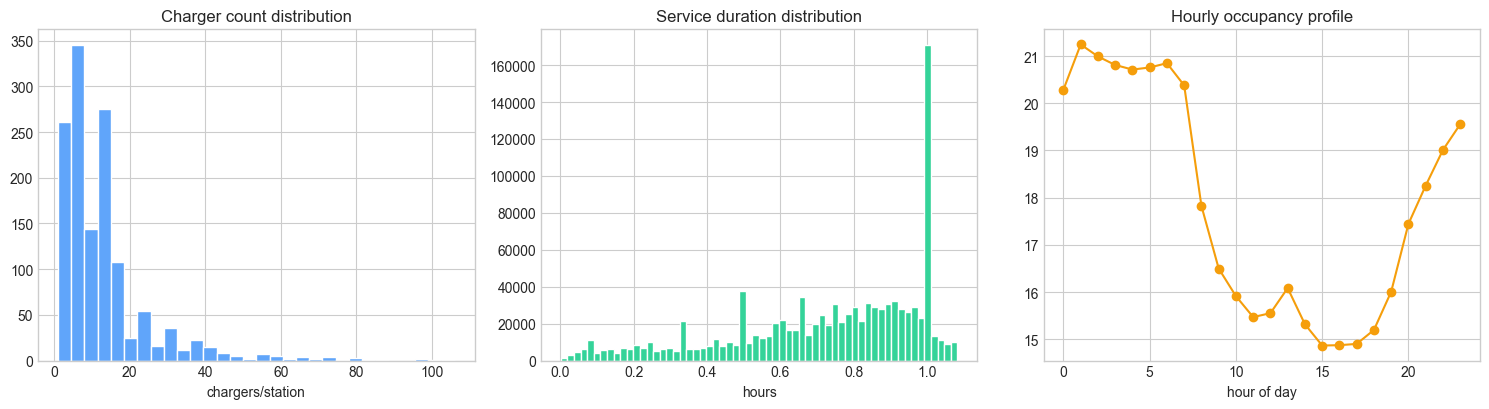

In [10]:
# Service duration sample
_dur = pd.read_csv(DATA_DIR / "duration.csv", index_col=0)
_occ = pd.read_csv(DATA_DIR / "occupancy.csv", index_col=0)
common = _dur.columns.intersection(_occ.columns)
arr_d = _dur[common].to_numpy().flatten().astype(float)
arr_o = _occ[common].to_numpy().flatten().astype(float)
mask = (arr_o > 0.5) & (arr_d > 0) & np.isfinite(arr_d) & np.isfinite(arr_o)
service_duration = arr_d[mask] / arr_o[mask]
service_duration = service_duration[service_duration <= np.percentile(service_duration, 95)]

desc = pd.Series(service_duration).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
print(desc)
print("Skewness:", pd.Series(service_duration).skew())
print("Kurtosis:", pd.Series(service_duration).kurt())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(df_inf["charge_count"], bins=30, color="#60a5fa", edgecolor="white")
axes[0].set_title("Charger count distribution")
axes[0].set_xlabel("chargers/station")

axes[1].hist(service_duration, bins=60, color="#34d399", edgecolor="white")
axes[1].set_title("Service duration distribution")
axes[1].set_xlabel("hours")

hourly_occ = _occ.copy()
hourly_occ.index = pd.to_datetime(hourly_occ.index)
hour_profile = hourly_occ.groupby(hourly_occ.index.hour).mean().mean(axis=1)
axes[2].plot(hour_profile.index, hour_profile.values, marker="o", color="#f59e0b")
axes[2].set_title("Hourly occupancy profile")
axes[2].set_xlabel("hour of day")

plt.tight_layout()
plt.show()

## 5) Input distribution fitting and parameter estimation

We compare candidate distributions for service duration and inspect goodness-of-fit statistics (informal teaching-level check).

In [11]:
# Fit exponential and gamma (Erlang-like)
exp_loc, exp_scale = stats.expon.fit(service_duration, floc=0)
g_shape, g_loc, g_scale = stats.gamma.fit(service_duration, floc=0)

ks_exp = stats.kstest(service_duration, "expon", args=(exp_loc, exp_scale))
ks_gamma = stats.kstest(service_duration, "gamma", args=(g_shape, g_loc, g_scale))

fit_df = pd.DataFrame([
    ["Exponential", exp_scale, np.nan, ks_exp.statistic, ks_exp.pvalue],
    ["Gamma/Erlang-like", g_scale, g_shape, ks_gamma.statistic, ks_gamma.pvalue],
], columns=["Distribution", "Scale", "Shape(k)", "KS statistic", "KS p-value"])
fit_df

,Distribution,Scale,Shape(k),KS statistic,KS p-value
0,Exponential,0.723872,NaN,0.312891,0.0
1,Gamma/Erlang-like,0.168429,4.297791,0.153633,0.0


## 6) Monte Carlo class design and call (Option A)

We define lightweight teaching wrappers (`InputDistribution`, `SimulationModel`, `ScenarioRunner`) and call project classes underneath.

In [12]:
from dataclasses import dataclass

@dataclass
class InputDistribution:
    name: str
    params: dict

class SimulationModel:
    def __init__(self, baseline: dict):
        self.baseline = baseline

    def run(self, occupancy_change=0.0, service_fee_change=0.0, electricity_cost_change=0.0, wait_cost_change=0.0, n_iter=1000):
        lam = self.baseline["lambda_rate"] * (1.0 + occupancy_change)
        wait_cost = self.baseline["wait_cost_per_minute"] * (1.0 + wait_cost_change)
        q = QueuingSimulator(
            lam=lam,
            mu=self.baseline["mu"],
            c=self.baseline["c"],
            service_time_cv=self.baseline["service_time_cv"],
        ).compute()

        mc = MonteCarloSimulator(
            daily_sessions=q.daily_sessions,
            mean_kwh=self.baseline["mean_kwh"],
            std_kwh=self.baseline["std_kwh"],
            mean_e_price=self.baseline["mean_e_price"],
            mean_s_price=self.baseline["mean_s_price"],
            std_e_price=self.baseline["std_e_price"],
            std_s_price=self.baseline["std_s_price"],
            wholesale_price=self.baseline["wholesale_price"],
            daily_fixed_cost=self.baseline["daily_fixed_cost"],
            mean_wait_minutes=q.wq_minutes,
            wait_cost_per_minute=wait_cost,
            service_fee_change=service_fee_change,
            electricity_cost_change=electricity_cost_change,
            n_iter=n_iter,
            seed=42,
        ).run()
        return q, mc

class ScenarioRunner:
    def __init__(self, model: SimulationModel):
        self.model = model

    def baseline(self):
        return self.model.run(n_iter=1000)

model = SimulationModel(baseline)
runner = ScenarioRunner(model)
q0, mc0 = runner.baseline()
print("Baseline util=", round(q0.rho, 4), "wait(min)=", round(q0.wq_minutes, 4), "mean profit=", round(mc0.mean_profit, 2))

Baseline util= 0.1708 wait(min)= 0.0 mean profit= 86.42


## 7) Queuing model class call (Option B)

We evaluate queue KPIs across demand shocks to examine stability and congestion behavior.

In [13]:
queue_rows = []
for oc in [-0.3, 0.0, 0.5, 1.0, 2.0]:
    q, mc = model.run(occupancy_change=oc, n_iter=1000)
    queue_rows.append([
        oc,
        q.rho,
        q.wq_mmc_minutes,
        q.wq_minutes,
        q.erlang_c,
        q.daily_sessions,
    ])

queue_df = pd.DataFrame(queue_rows, columns=[
    "occupancy_change",
    "utilization_rho",
    "wait_mmc_minutes",
    "wait_mgc_minutes",
    "prob_wait",
    "daily_sessions",
])
queue_df

,occupancy_change,utilization_rho,wait_mmc_minutes,wait_mgc_minutes,prob_wait,daily_sessions
0,-0.3,0.119592,4.533424e-08,2.568705e-08,1.194650e-08,51.546118
1,0.0,0.170846,2.709436e-06,1.535207e-06,6.724262e-07,73.637312
2,0.5,0.256269,2.158836e-04,1.223229e-04,4.805803e-05,110.455967
3,1.0,0.341692,3.820305e-03,2.164642e-03,7.527619e-04,147.274623
4,2.0,0.512538,1.467916e-01,8.317428e-02,2.141767e-02,220.911935


## 8) Risk metrics and steady-state indicators

For Monte Carlo: VaR, CVaR, probability of loss.

For queuing: waiting time, queue length proxy, utilization, probability of waiting.

In [14]:
profits = np.array(mc0.profits)
var5 = np.percentile(profits, 5)
cvar5 = profits[profits <= var5].mean()
loss_prob = (profits < 0).mean()

risk_table = pd.DataFrame([
    ["Expected profit", profits.mean()],
    ["Std of profit", profits.std()],
    ["VaR 5%", var5],
    ["CVaR 5%", cvar5],
    ["Probability of loss", loss_prob],
    ["Utilization rho", q0.rho],
    ["Mean wait (M/M/c, min)", q0.wq_mmc_minutes],
    ["Mean wait (M/G/c, min)", q0.wq_minutes],
], columns=["Metric", "Value"])
risk_table

,Metric,Value
0,Expected profit,86.417461
1,Std of profit,198.748918
2,VaR 5%,-210.349841
3,CVaR 5%,-221.809770
4,Probability of loss,0.371000
5,Utilization rho,0.170846
6,"Mean wait (M/M/c, min)",0.000003
7,"Mean wait (M/G/c, min)",0.000002


## 9) Sensitivity analysis and tornado chart

We perturb key inputs one at a time and compare expected-profit changes.

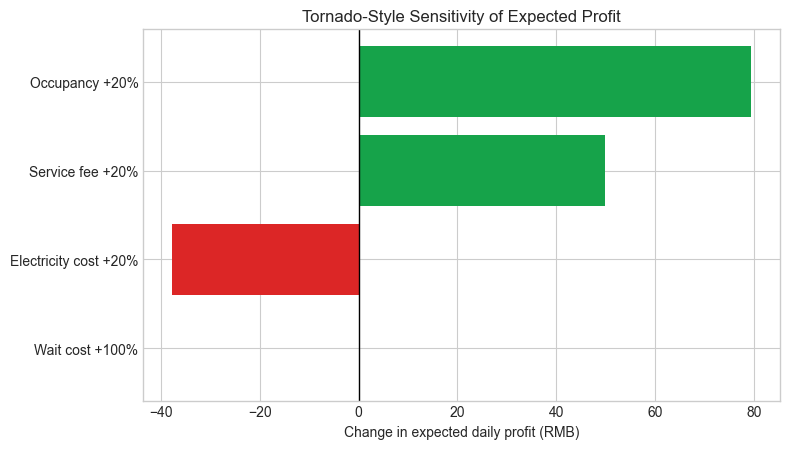

In [15]:
scenarios = {
    "Service fee +20%": dict(service_fee_change=0.2),
    "Electricity cost +20%": dict(electricity_cost_change=0.2),
    "Occupancy +20%": dict(occupancy_change=0.2),
    "Wait cost +100%": dict(wait_cost_change=1.0),
}

base_mean = profits.mean()
delta = {}
for k, cfg in scenarios.items():
    q, mc = model.run(
        occupancy_change=cfg.get("occupancy_change", 0.0),
        service_fee_change=cfg.get("service_fee_change", 0.0),
        electricity_cost_change=cfg.get("electricity_cost_change", 0.0),
        wait_cost_change=cfg.get("wait_cost_change", 0.0),
        n_iter=1000,
    )
    delta[k] = np.mean(mc.profits) - base_mean

labels = list(delta.keys())
values = np.array([delta[k] for k in labels])
order = np.argsort(np.abs(values))
labels = [labels[i] for i in order]
values = values[order]

plt.figure(figsize=(8, 4.6))
plt.barh(labels, values, color=["#16a34a" if v >= 0 else "#dc2626" for v in values])
plt.axvline(0, color="black", linewidth=1)
plt.title("Tornado-Style Sensitivity of Expected Profit")
plt.xlabel("Change in expected daily profit (RMB)")
plt.tight_layout()
plt.show()

## 10) Project flowchart generation and embedding

Mermaid flowchart for report/notebook embedding:

```mermaid
flowchart LR
    A[Input Data] --> B[Cleaning & Parameter Estimation]
    B --> C[Queue Model M/M/c]
    C --> D[M/G/c Correction]
    D --> E[Monte Carlo 1000+ Iterations]
    E --> F[Risk Metrics VaR/CVaR/Loss Prob]
    F --> G[Sensitivity & Recommendations]
```


## 11) visualization.py integration for report-ready figures

Run centralized plotting script and preview generated assets.

In [16]:
import subprocess

cmd = [str(ROOT / ".venv" / "bin" / "python"), str(ROOT / "visualization.py")]
print("Running:", " ".join(cmd))
_ = subprocess.run(cmd, cwd=str(ROOT), check=True, capture_output=True, text=True)
print(_.stdout.splitlines()[-3:])

assets = sorted([p.name for p in ASSET_DIR.glob("*.png")])
assets

Running: /Users/zhuzelin/Desktop/sr/小组作业/.venv/bin/python /Users/zhuzelin/Desktop/sr/小组作业/visualization.py
['               Mean service duration (hours)    0.7239          duration/occupancy', '', 'All figures generated in: /Users/zhuzelin/Desktop/sr/小组作业/report_assets']


['fig_01_charge_count_distribution.png',
 'fig_02_service_duration_distribution.png',
 'fig_03_profit_distribution_var_cvar.png',
 'fig_04_queue_sensitivity_curve.png',
 'fig_05_tornado_sensitivity.png',
 'fig_06_wait_penalty_response.png']

## 12) Teaching summary and decision recommendations

### What this notebook demonstrates

- End-to-end data-to-decision pipeline.
- Option A and Option B integration.
- Class-based implementation and scenario analysis.
- Report-ready figures and reproducible outputs.

### Managerial recommendations

1. Monitor utilization and wait-time thresholds in real time.
2. Use dynamic service fee or queue control during demand peaks.
3. Plan capacity expansion where sensitivity indicates strongest risk reduction.

### Limitations

- Hourly aggregated data limits event-level validation.
- Future work can use discrete-event simulation with timestamp-level logs.
